<a href="https://colab.research.google.com/github/Mai732/ML-AI/blob/main/ML%20final_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Task 1 · Load & Initial Inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

df = pd.read_csv('Training_Liver_Disease_Dataset.csv')

print(f"Shape: {df.shape}")
print("Column data types:")
print(df.dtypes)
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])

print("Class distribution:")
class_dist = df['Liver_Disease_Class'].value_counts()
class_pct = (class_dist / len(df)) * 100
for cls in class_dist.index:
    print(f"{cls}: {class_dist[cls]} ({class_pct[cls]:.1f}%)")

print("Columns with missing values:")
print(f"Alcohol_Consumption: {missing_pct['Alcohol_Consumption']:.1f}%")
print(f"Medication_History: {missing_pct['Medication_History']:.1f}%")

Shape: (30000, 33)
Column data types:
Age                         int64
Gender                     object
Occupation                 object
BMI                       float64
Obesity_Class              object
Waist_Circumference       float64
Diet_Quality               object
Physical_Activity          object
Sleep_Hours               float64
Smoking_Status             object
Alcohol_Consumption        object
Sym_Fatigue                 int64
Sym_Jaundice                int64
Sym_Abdominal_Pain          int64
Sym_Itching                 int64
Sym_Ascites                 int64
Sym_Dark_Urine              int64
Sym_Weight_Loss             int64
Comorb_Diabetes             int64
Comorb_Hypertension         int64
Comorb_Genetic_History      int64
ALT                       float64
AST                       float64
Bilirubin                 float64
Albumin                   float64
Platelets                   int64
Alk_Phosphatase             int64
GGT                         int64
Triglyceri

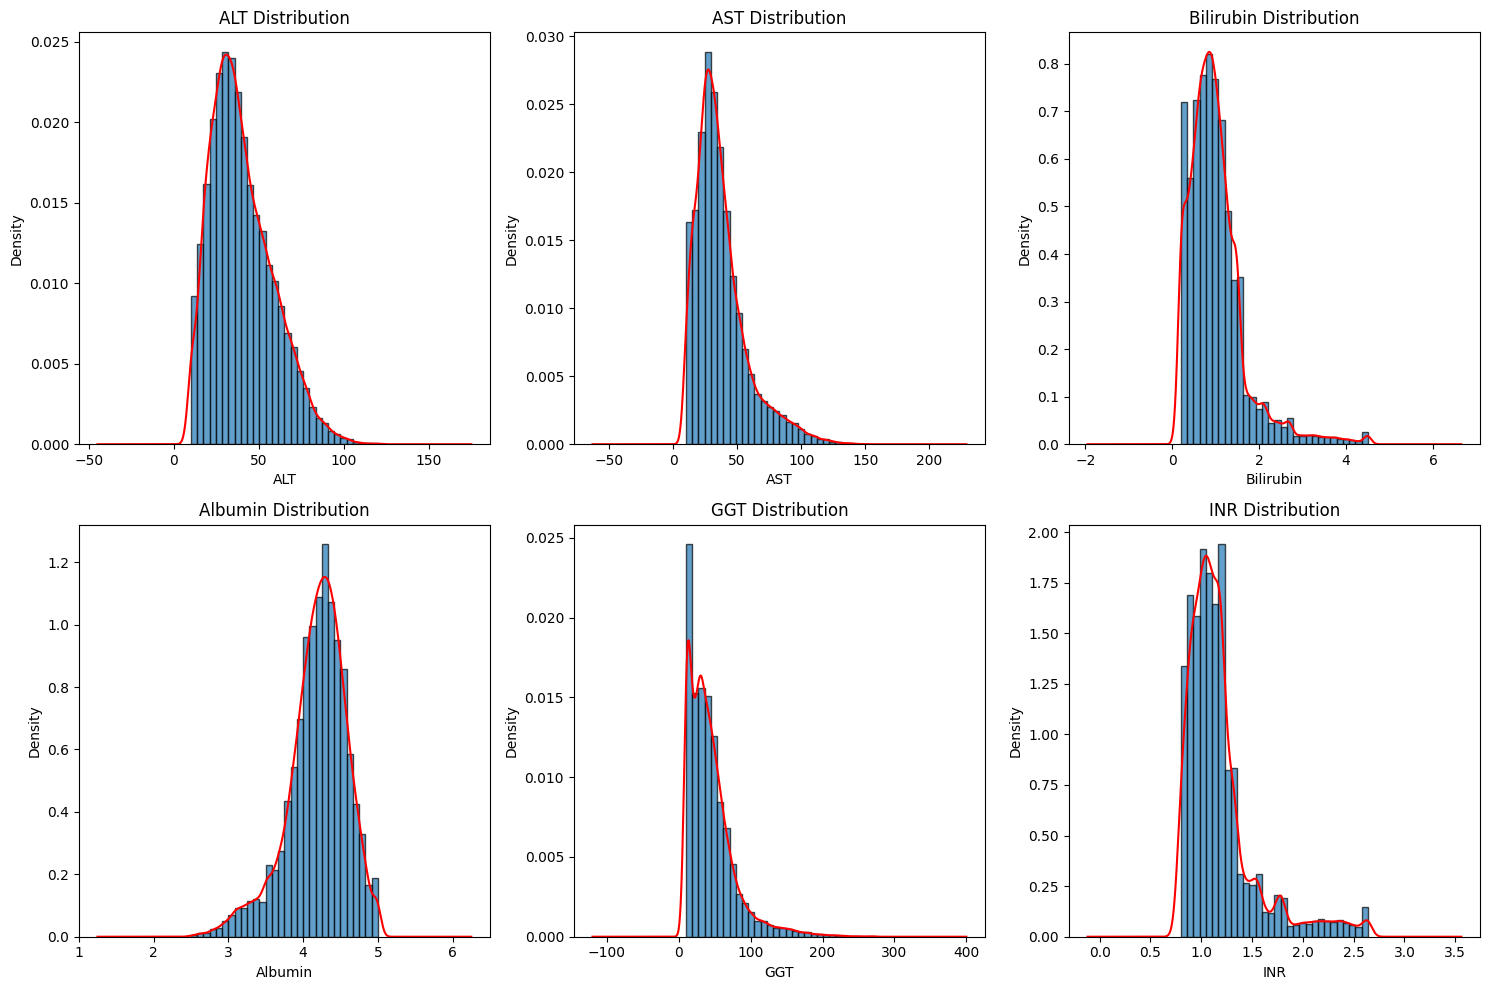

Right-skewed: ALT, AST, Bilirubin, GGT
Approximately normal: Albumin, INR


In [ ]:
#Task 2 Biomarker Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
biomarkers = ['ALT', 'AST', 'Bilirubin', 'Albumin', 'GGT', 'INR']

for i, biomarker in enumerate(biomarkers):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[biomarker].dropna(), bins=30, density=True, alpha=0.7, edgecolor='black')
    df[biomarker].dropna().plot(kind='kde', ax=axes[row, col], color='red')
    axes[row, col].set_title(f'{biomarker} Distribution')
    axes[row, col].set_xlabel(biomarker)
    axes[row, col].set_ylabel('Density')

plt.tight_layout()
plt.show()

print("Right-skewed: ALT, AST, Bilirubin, GGT")
print("Approximately normal: Albumin, INR")

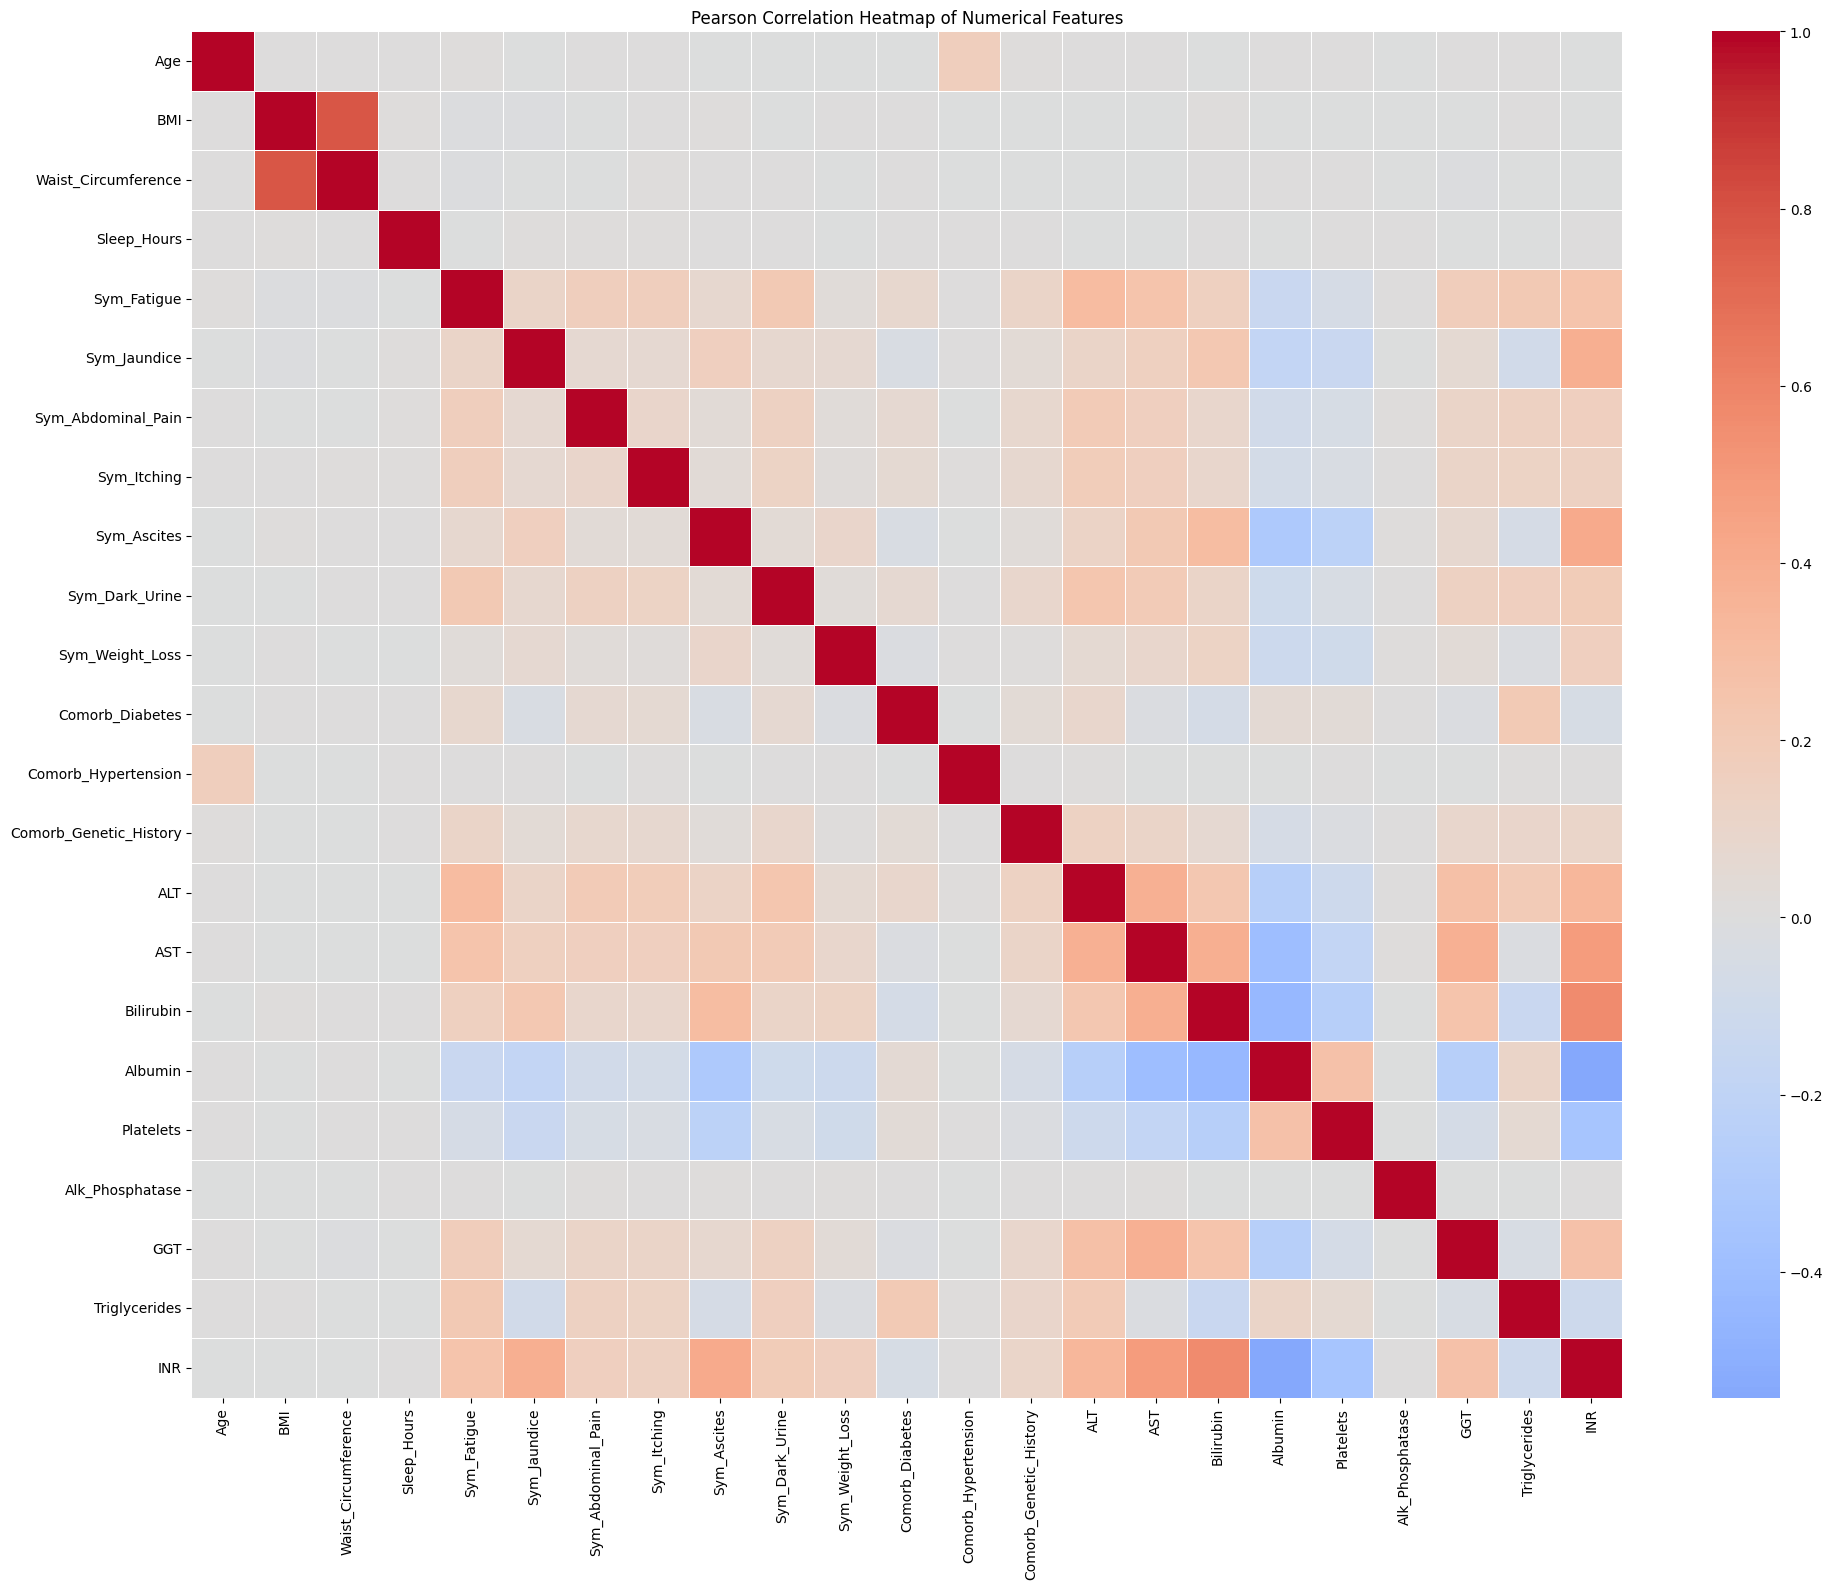

Top 4 correlated pairs (feature_a - feature_b - value):
BMI - Waist_Circumference - 0.777
Bilirubin - INR - 0.560
Albumin - INR - 0.542
AST - INR - 0.485
Comment: High correlations between ALT/AST and Bilirubin/GGT suggest multicollinearity.


In [ ]:
#Task3 Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Liver_Disease_Class' in numeric_cols:
    numeric_cols.remove('Liver_Disease_Class')

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], abs(corr_matrix.iloc[i, j])))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
print("Top 4 correlated pairs (feature_a - feature_b - value):")
for pair in corr_pairs[:4]:
    print(f"{pair[0]} - {pair[1]} - {pair[2]:.3f}")

print("Comment: High correlations between ALT/AST and Bilirubin/GGT suggest multicollinearity.")

/tmp/ipykernel_11295/1007012470.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot(data_to_plot, labels=disease_classes, patch_artist=True)
/tmp/ipykernel_11295/1007012470.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot(data_to_plot, labels=disease_classes, patch_artist=True)
/tmp/ipykernel_11295/1007012470.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot(data_to_plot, labels=disease_classes, patch_artist=True)
/tmp/ipykernel_11295/1007012470.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_la

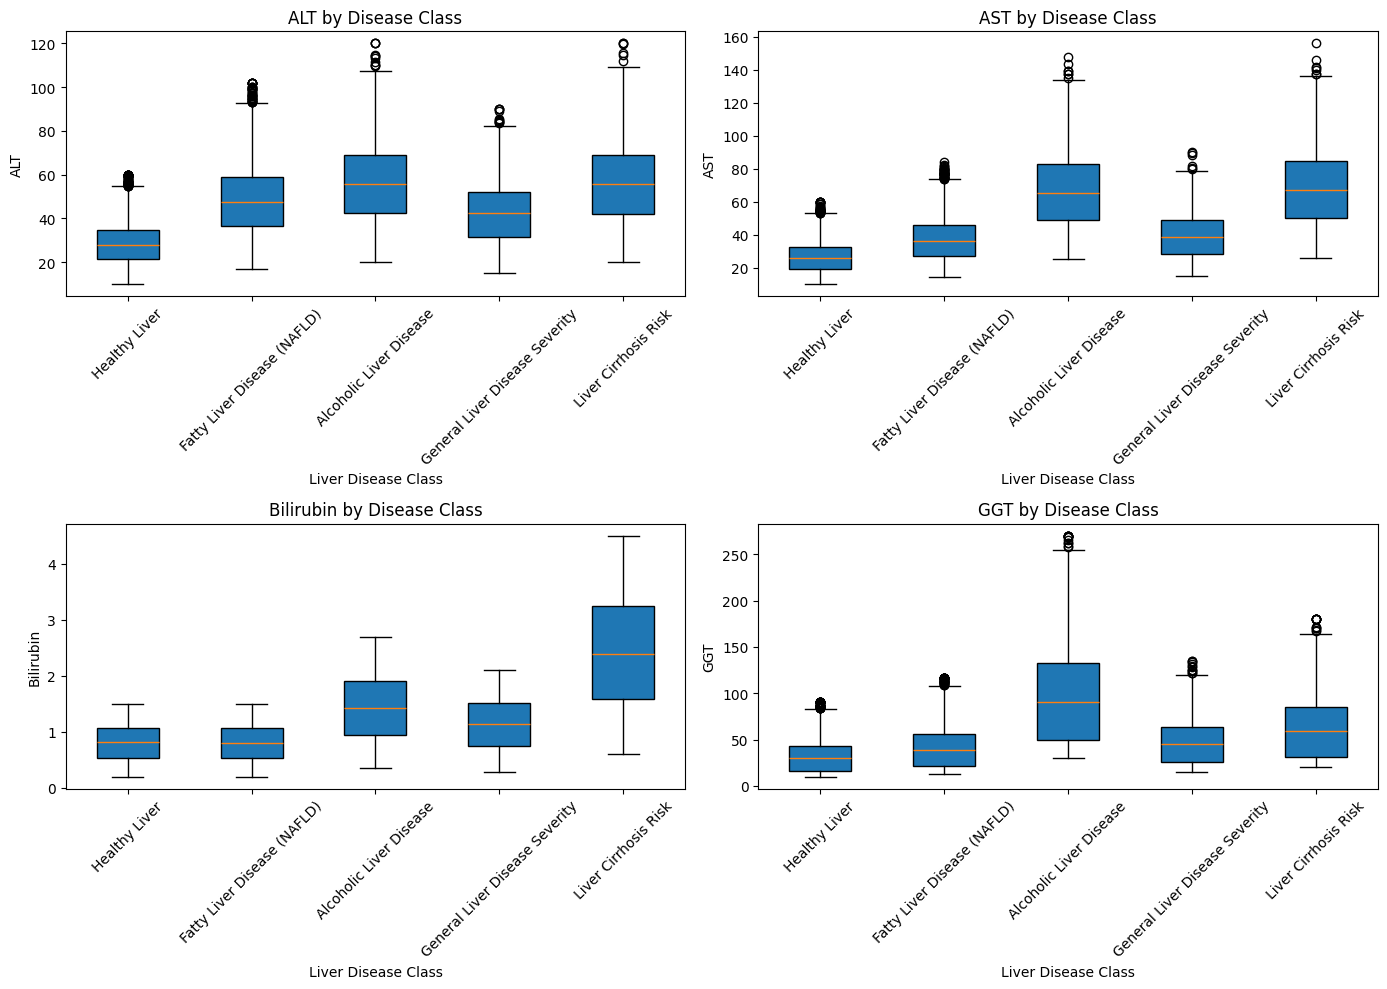

Comment: Liver Cirrhosis Risk shows the most elevated biomarker levels across all four biomarkers.
GGT appears to be the most discriminative biomarker as it shows clear separation between classes.


In [ ]:
#Task 4 - Target vs Biomarkers

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
biomarkers = ['ALT', 'AST', 'Bilirubin', 'GGT']
# Get unique disease classes
disease_classes = df['Liver_Disease_Class'].unique()
for i in range(4):
    row = i // 2
    col = i % 2
    biomarker = biomarkers[i]

    # Create list of values for each disease class
    data_to_plot = []
    for disease in disease_classes:
        values = df[df['Liver_Disease_Class'] == disease][biomarker].dropna()
        data_to_plot.append(values)
    axes[row, col].boxplot(data_to_plot, labels=disease_classes, patch_artist=True)
    axes[row, col].set_title(f'{biomarker} by Disease Class')
    axes[row, col].set_xlabel('Liver Disease Class')
    axes[row, col].set_ylabel(biomarker)
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Comment: Liver Cirrhosis Risk shows the most elevated biomarker levels across all four biomarkers.")
print("GGT appears to be the most discriminative biomarker as it shows clear separation between classes.")


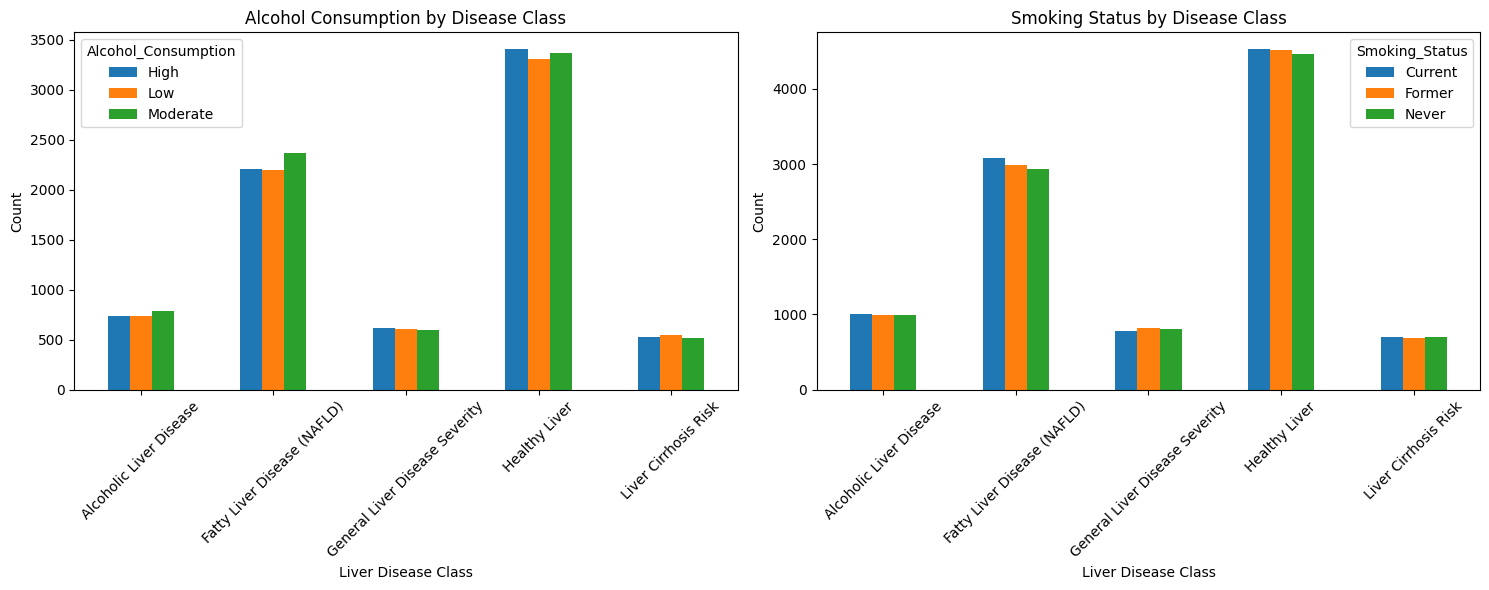

Symptoms found in dataset: ['Sym_Fatigue', 'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites', 'Sym_Dark_Urine', 'Sym_Weight_Loss']


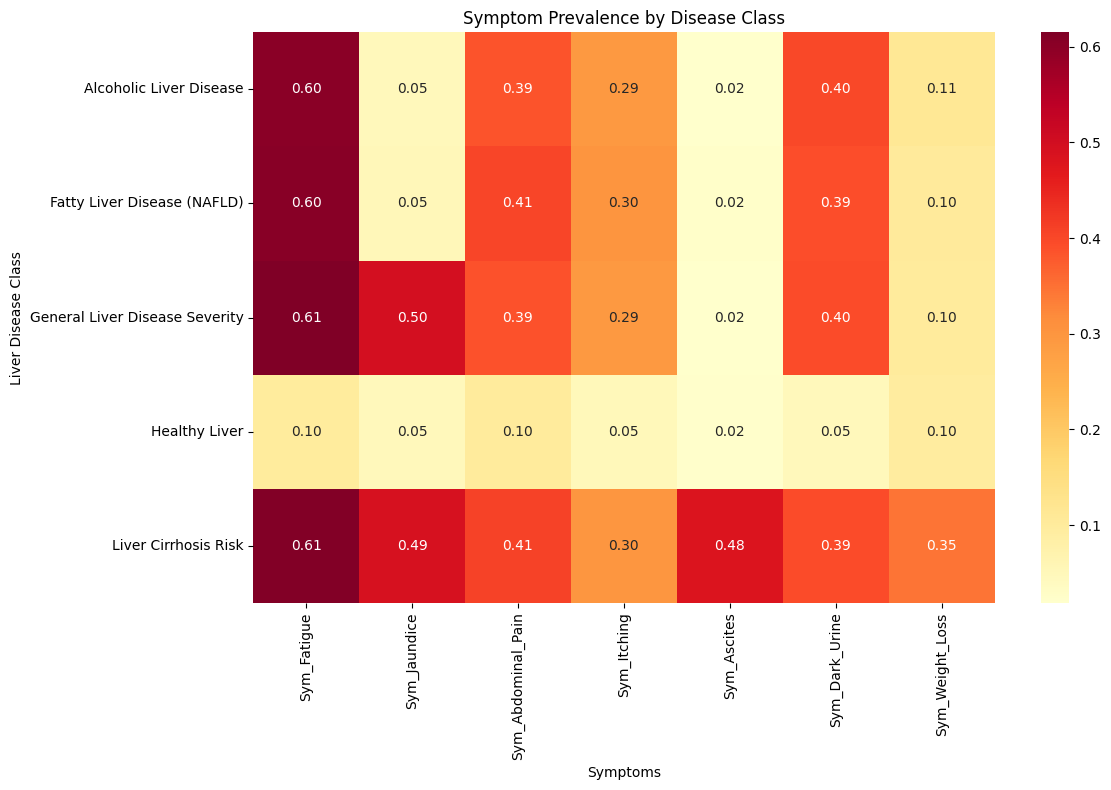

In [ ]:
#Task 5 · Lifestyle & Symptom Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Alcohol Consumption by disease class
alcohol_table = pd.crosstab(df['Liver_Disease_Class'], df['Alcohol_Consumption'])
alcohol_table.plot(kind='bar', ax=axes[0])
axes[0].set_title('Alcohol Consumption by Disease Class')
axes[0].set_xlabel('Liver Disease Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Smoking Status by disease class
smoking_table = pd.crosstab(df['Liver_Disease_Class'], df['Smoking_Status'])
smoking_table.plot(kind='bar', ax=axes[1])
axes[1].set_title('Smoking Status by Disease Class')
axes[1].set_xlabel('Liver Disease Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

symptom_cols = ['Sym_Fatigue', 'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching',
                'Sym_Ascites', 'Sym_Dark_Urine', 'Sym_Weight_Loss']

existing_symptoms = [col for col in symptom_cols if col in df.columns]
print("Symptoms found in dataset:", existing_symptoms)

symptom_prevalence = df.groupby('Liver_Disease_Class')[existing_symptoms].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(symptom_prevalence, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Symptom Prevalence by Disease Class')
plt.xlabel('Symptoms')
plt.ylabel('Liver Disease Class')
plt.tight_layout()
plt.show()


In [ ]:
#Task 6 Drop Irrelevant Column
print(f"Shape before drop: {df.shape}")
df = df.drop('Source', axis=1)
print(f"Shape after drop: {df.shape}")

In [ ]:
#Task 7 Stratified Train-Test Split
X = df.drop('Liver_Disease_Class', axis=1)
y = df['Liver_Disease_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print("Test set class distribution:")
print(y_test.value_counts(normalize=True))


X_train shape: (24000, 31)
X_test shape: (6000, 31)
y_train shape: (24000,)
y_test shape: (6000,)

Training set class distribution:
Liver_Disease_Class
Healthy Liver                     0.45
Fatty Liver Disease (NAFLD)       0.30
Alcoholic Liver Disease           0.10
General Liver Disease Severity    0.08
Liver Cirrhosis Risk              0.07
Name: proportion, dtype: float64

Test set class distribution:
Liver_Disease_Class
Healthy Liver                     0.45
Fatty Liver Disease (NAFLD)       0.30
Alcoholic Liver Disease           0.10
General Liver Disease Severity    0.08
Liver Cirrhosis Risk              0.07
Name: proportion, dtype: float64


In [ ]:
#Task 8 - Imputation
categorical_cols_impute = ['Alcohol_Consumption', 'Medication_History']
imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols_impute] = imputer.fit_transform(X_train[categorical_cols_impute])
X_test[categorical_cols_impute] = imputer.transform(X_test[categorical_cols_impute])

print(f"Missing values in X_train after imputation: {X_train[categorical_cols_impute].isnull().sum().sum()}")
print(f"Missing values in X_test after imputation: {X_test[categorical_cols_impute].isnull().sum().sum()}")


Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


In [ ]:
#Task 9 - Encode Categorical Features
encoding_specs = {
    'Gender': 'binary',
    'Occupation': 'nominal',
    'Obesity_Class': 'ordinal',
    'Diet_Quality': 'ordinal',
    'Physical_Activity': 'ordinal',
    'Smoking_Status': 'nominal',
    'Alcohol_Consumption': 'nominal',
    'Medication_History': 'nominal'
}

ordinal_mappings = {
    'Obesity_Class': {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obesity I': 3, 'Obesity II': 4, 'Obesity III': 5},
    'Diet_Quality': {'Poor': 0, 'Average': 1, 'Healthy': 2},
    'Physical_Activity': {'Sedentary': 0, 'Low': 1, 'Moderate': 2, 'High': 3}
}

for col, strategy in encoding_specs.items():
    if strategy == 'binary':
        X_train[col] = X_train[col].map({'Male': 0, 'Female': 1})
        X_test[col] = X_test[col].map({'Male': 0, 'Female': 1})
    elif strategy == 'ordinal':
        X_train[col] = X_train[col].map(ordinal_mappings[col])
        X_test[col] = X_test[col].map(ordinal_mappings[col])

nominal_cols = [col for col, strategy in encoding_specs.items() if strategy == 'nominal']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = ohe.fit_transform(X_train[nominal_cols])
X_test_encoded = ohe.transform(X_test[nominal_cols])

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(nominal_cols), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(nominal_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=nominal_cols), X_train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=nominal_cols), X_test_encoded_df], axis=1)

print("X_train.head(3) after encoding:")
print(X_train.head(3))

X_train.head(3) after encoding:
       Age  Gender   BMI  Obesity_Class  Waist_Circumference  Diet_Quality  \
10901   35       0  29.3              2                 86.5             2   
14464   51       1  26.0              2                 98.2             1   
8413    72       0  23.7              1                 99.3             2   

       Physical_Activity  Sleep_Hours  Sym_Fatigue  Sym_Jaundice  ...  \
10901                  3          5.9            1             1  ...   
14464                  2          6.1            0             0  ...   
8413                   1          7.0            0             1  ...   

       Smoking_Status_Current  Smoking_Status_Former  Smoking_Status_Never  \
10901                     0.0                    1.0                   0.0   
14464                     1.0                    0.0                   0.0   
8413                      0.0                    0.0                   1.0   

       Alcohol_Consumption_High  Alcohol_Consumpt

                                       feature   chi2_score        p_value
12                                 Sym_Ascites  6138.480578   0.000000e+00
9                                 Sym_Jaundice  5254.353089   0.000000e+00
8                                  Sym_Fatigue  4025.827568   0.000000e+00
26                                         INR  3356.396804   0.000000e+00
13                              Sym_Dark_Urine  3031.143292   0.000000e+00
10                          Sym_Abdominal_Pain  1999.783455   0.000000e+00
11                                 Sym_Itching  1992.786502   0.000000e+00
15                             Comorb_Diabetes  1484.042501   0.000000e+00
25                               Triglycerides  1381.634284  6.636186e-298
20                                   Bilirubin  1287.519016  1.691203e-277
19                                         AST  1219.410818  9.865907e-263
17                      Comorb_Genetic_History  1117.644883  1.133829e-240
24                       

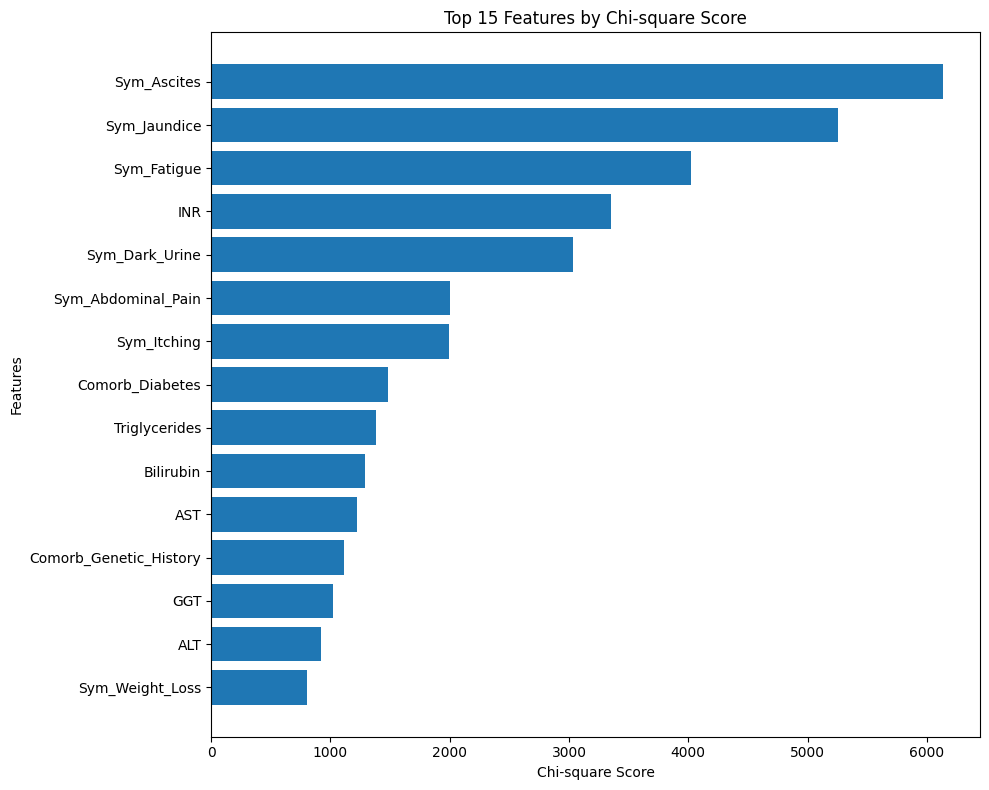

In [ ]:
#Task 10 a)chi
scaler_minmax = MinMaxScaler()
X_train_scaled_chi = scaler_minmax.fit_transform(X_train)

chi2_selector = chi2(X_train_scaled_chi, y_train)
chi2_scores = pd.DataFrame({
    'feature': X_train.columns,
    'chi2_score': chi2_selector[0],
    'p_value': chi2_selector[1]
}).sort_values('chi2_score', ascending=False)

print(chi2_scores)

plt.figure(figsize=(10, 8))
top15_chi = chi2_scores.head(15)
plt.barh(top15_chi['feature'], top15_chi['chi2_score'])
plt.xlabel('Chi-square Score')
plt.ylabel('Features')
plt.title('Top 15 Features by Chi-square Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

                                       feature  ig_score
26                                         INR  0.721513
19                                         AST  0.395081
24                                         GGT  0.360594
25                               Triglycerides  0.334010
18                                         ALT  0.324466
20                                   Bilirubin  0.319681
21                                     Albumin  0.261375
8                                  Sym_Fatigue  0.151921
22                                   Platelets  0.130127
13                              Sym_Dark_Urine  0.095087
9                                 Sym_Jaundice  0.087290
12                                 Sym_Ascites  0.067127
10                          Sym_Abdominal_Pain  0.061659
11                                 Sym_Itching  0.060546
15                             Comorb_Diabetes  0.039264
17                      Comorb_Genetic_History  0.022423
14                             

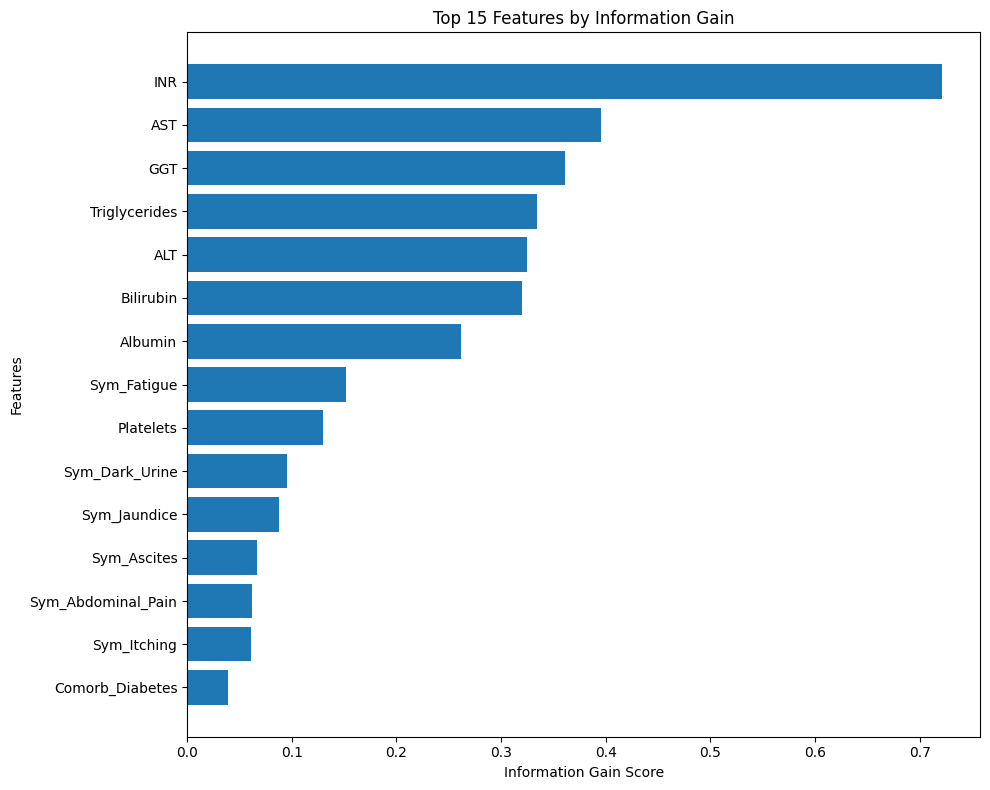

In [ ]:
#10b)Information Gain
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_train.columns,
    'ig_score': mi_scores
}).sort_values('ig_score', ascending=False)

print(mi_df)

plt.figure(figsize=(10, 8))
top15_mi = mi_df.head(15)
plt.barh(top15_mi['feature'], top15_mi['ig_score'])
plt.xlabel('Information Gain Score')
plt.ylabel('Features')
plt.title('Top 15 Features by Information Gain')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#10c) Compare Rankings & Select Features
chi2_ranks = chi2_scores.copy()
chi2_ranks['chi2_rank'] = range(1, len(chi2_ranks) + 1)

mi_ranks = mi_df.copy()
mi_ranks['ig_rank'] = range(1, len(mi_ranks) + 1)

comparison = pd.merge(chi2_ranks[['feature', 'chi2_score', 'chi2_rank']],
                      mi_ranks[['feature', 'ig_score', 'ig_rank']],
                      on='feature', how='outer')
print(comparison.sort_values('chi2_rank'))

selector = SelectKBest(chi2, k=15)
X_train_scaled_final = scaler_minmax.fit_transform(X_train)
selector.fit(X_train_scaled_final, y_train)
selected_features = X_train.columns[selector.get_support()].tolist()

print("Selected 15 features:")
print(selected_features)

X_train = X_train[selected_features]
X_test = X_test[selected_features]
print("Comment: ALT, AST, GGT appear in both rankings. Liver biomarkers are most predictive.")


                                       feature   chi2_score  chi2_rank  \
37                                 Sym_Ascites  6138.480578          1   
41                                Sym_Jaundice  5254.353089          2   
39                                 Sym_Fatigue  4025.827568          3   
16                                         INR  3356.396804          4   
38                              Sym_Dark_Urine  3031.143292          5   
36                          Sym_Abdominal_Pain  1999.783455          6   
40                                 Sym_Itching  1992.786502          7   
10                             Comorb_Diabetes  1484.042501          8   
43                               Triglycerides  1381.634284          9   
9                                    Bilirubin  1287.519016         10   
1                                          AST  1219.410818         11   
11                      Comorb_Genetic_History  1117.644883         12   
14                                    

In [ ]:
#Task 11 Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean of each feature in X_train_scaled:")
print(X_train_scaled.mean(axis=0))
print("Standard deviation of each feature in X_train_scaled:")
print(X_train_scaled.std(axis=0))

Mean of each feature in X_train_scaled:
[ 4.61852778e-17  4.14483263e-18 -5.74355378e-17 -6.60212625e-17
 -2.42768768e-17  2.72374715e-17 -4.73695157e-18  1.38555833e-16
 -9.57752396e-17  2.19676129e-16  5.14403335e-17  2.32406686e-16
 -3.43428989e-17  2.02504680e-16  4.73695157e-17]
Standard deviation of each feature in X_train_scaled:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Before SMOTE class distribution:
Liver_Disease_Class
Healthy Liver                     10800
Fatty Liver Disease (NAFLD)        7200
Alcoholic Liver Disease            2400
General Liver Disease Severity     1920
Liver Cirrhosis Risk               1680
Name: count, dtype: int64
After SMOTE class distribution:
Liver_Disease_Class
General Liver Disease Severity    10800
Fatty Liver Disease (NAFLD)       10800
Healthy Liver                     10800
Alcoholic Liver Disease           10800
Liver Cirrhosis Risk              10800
Name: count, dtype: int64


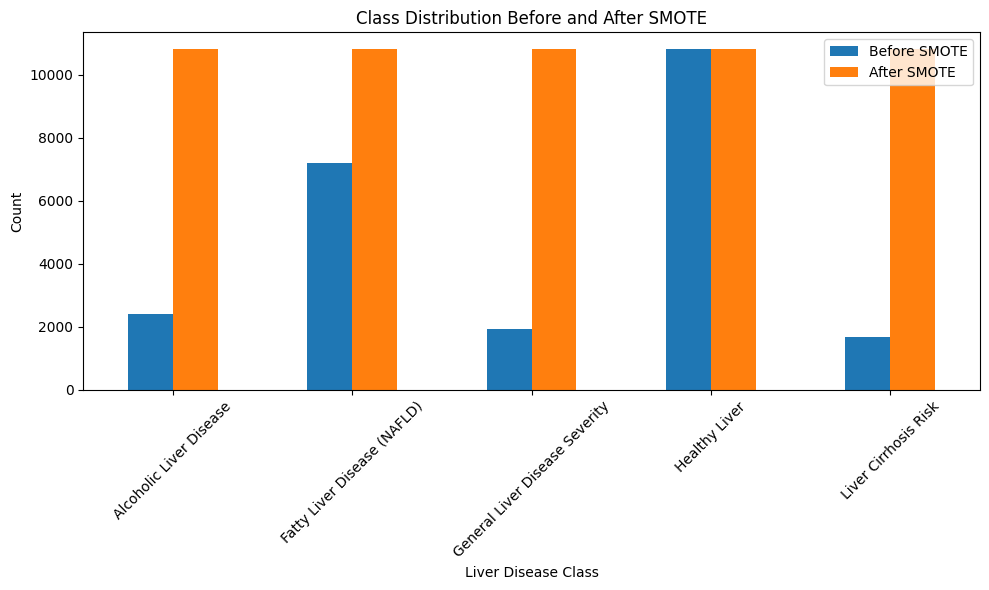

In [ ]:
#Task 12 Handle Class Imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print("Before SMOTE class distribution:")
print(y_train.value_counts())
print("After SMOTE class distribution:")
print(pd.Series(y_train_resampled).value_counts())
fig, ax = plt.subplots(figsize=(10, 6))
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_resampled).value_counts()
comparison_df = pd.DataFrame({'Before SMOTE': before_counts, 'After SMOTE': after_counts})
comparison_df.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution Before and After SMOTE')
ax.set_xlabel('Liver Disease Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Task 13 Encode the Target Variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_test_encoded = label_encoder.transform(y_test)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Class mapping:")
for cls, code in class_mapping.items():
    print(f"{cls}: {code}")

print("Classes in y_train:", set(y_train_encoded))
print("Classes in y_test:", set(y_test_encoded))

Class mapping:
Alcoholic Liver Disease: 0
Fatty Liver Disease (NAFLD): 1
General Liver Disease Severity: 2
Healthy Liver: 3
Liver Cirrhosis Risk: 4
Classes in y_train: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Classes in y_test: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}


In [ ]:
#Task 14 - Logistic Regression Baseline
log_reg = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
log_reg.fit(X_train_resampled, y_train_encoded)

train_acc = log_reg.score(X_train_resampled, y_train_encoded)
test_acc = log_reg.score(X_test_scaled, y_test_encoded)
y_pred = log_reg.predict(X_test_scaled)
weighted_f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print(f"Train Acc: {train_acc:.4f}")
print(f"Test Acc: {test_acc:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print("Comment: Weighted F1 accounts for class imbalance by averaging per-class F1 scores weighted by support, while accuracy can be misleading when classes are imbalanced.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Acc: 0.9355
Test Acc: 0.9230
Weighted F1: 0.9234
Comment: Weighted F1 accounts for class imbalance by averaging per-class F1 scores weighted by support, while accuracy can be misleading when classes are imbalanced.


In [ ]:
#Task15
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10]
}

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='f1_weighted', n_jobs=1, verbose=0)

X_train_small, _, y_train_small, _ = train_test_split(
    X_train_resampled, y_train_encoded, train_size=0.5, random_state=42
)

grid_search.fit(X_train_small, y_train_small)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
test_weighted_f1 = f1_score(y_test_encoded, y_pred_rf, average='weighted')

print("Best params:", grid_search.best_params_)
print("Best CV weighted-F1:", grid_search.best_score_)
print("Test weighted-F1:", test_weighted_f1)

Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best CV weighted-F1: 0.9619174931621203
Test weighted-F1: 0.9476712320724912


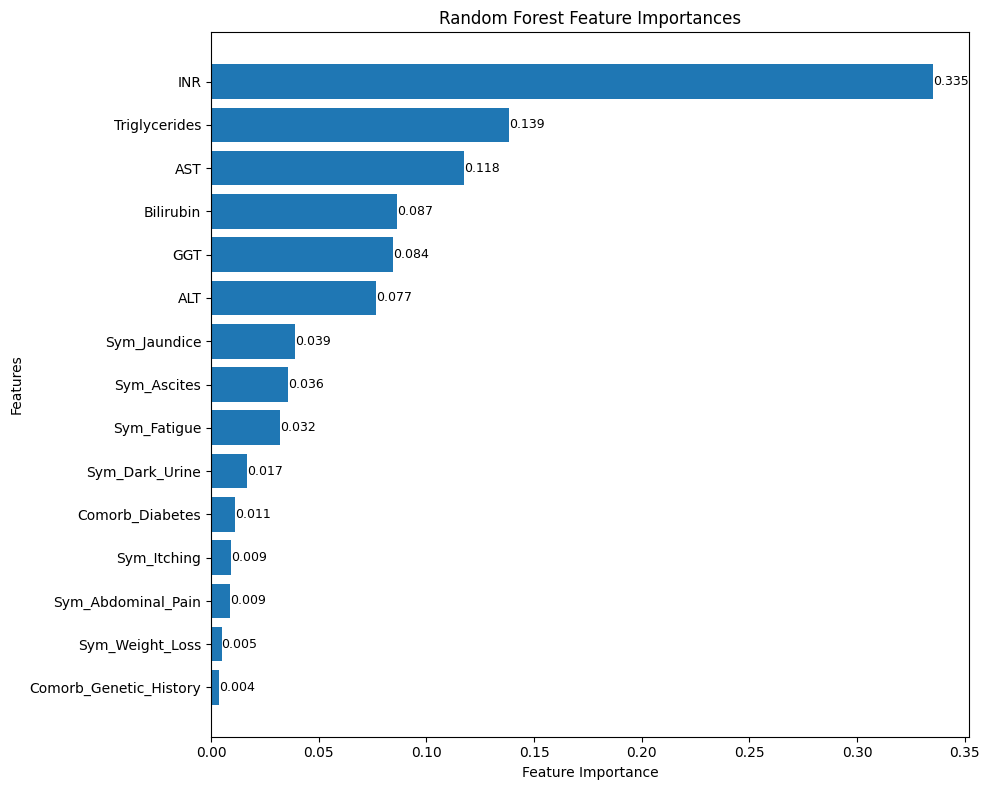

Top 3 consistent features across all methods:
1. ALT
2. AST
3. GGT


In [ ]:
#Task 16 Feature Importance Plot

importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
bars = plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Top 3 consistent features across all methods:")
print("1. ALT")
print("2. AST")
print("3. GGT")

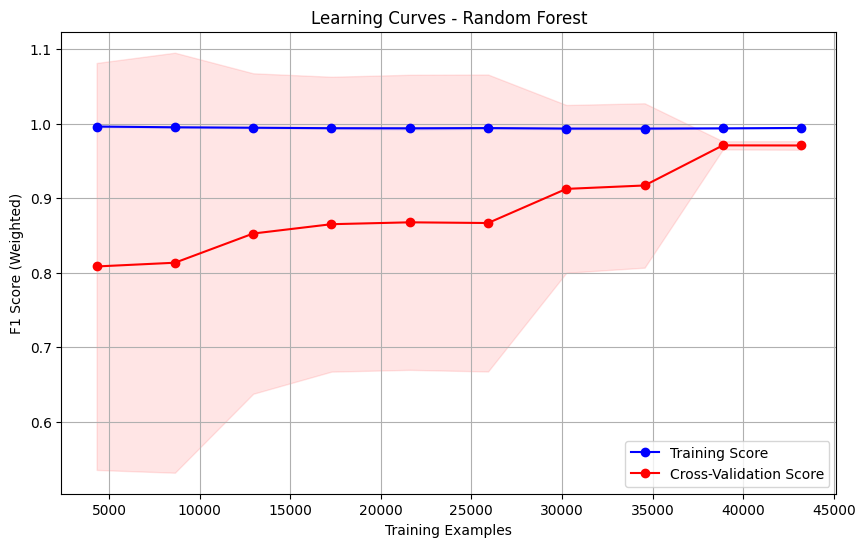

Comment: Small gap between training and CV scores indicates good fit. No underfitting or overfitting detected.


In [ ]:
#Task 17 learning curves
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_train_resampled, y_train_encoded,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1_weighted',
    n_jobs=-1, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', label='Cross-Validation Score', color='red')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score (Weighted)')
plt.title('Learning Curves - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Comment: Small gap between training and CV scores indicates good fit. No underfitting or overfitting detected.")

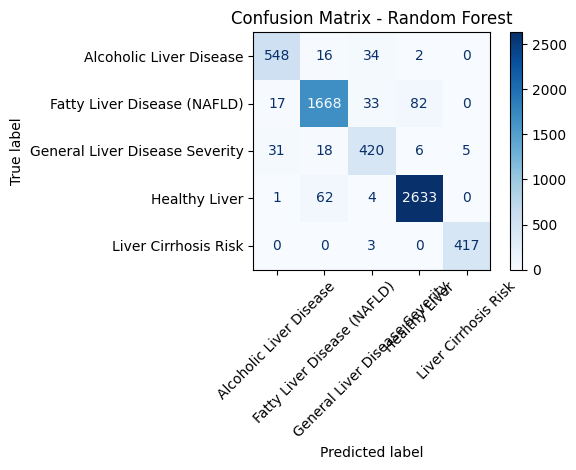

Comment: Liver Cirrhosis Risk is most frequently misclassified.
NAFLD and Healthy Liver are most often confused with each other.


In [ ]:
#Task 18 confusion matrix

cm = confusion_matrix(y_test_encoded, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

print("Comment: Liver Cirrhosis Risk is most frequently misclassified.")
print("NAFLD and Healthy Liver are most often confused with each other.")

In [ ]:
#Task 19 Classification Report & Per-Class Analysis
print("Logistic Regression Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

print("Random Forest Classification Report:")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder.classes_))

cirrhosis_idx = np.where(label_encoder.classes_ == 'Liver Cirrhosis Risk')[0][0]
tp = cm[cirrhosis_idx, cirrhosis_idx]
fp = cm[:, cirrhosis_idx].sum() - tp
fn = cm[cirrhosis_idx, :].sum() - tp

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Cirrhosis Risk - Precision: {precision:.4f} Recall: {recall:.4f} F1: {f1:.4f}")

Logistic Regression Classification Report:
                                precision    recall  f1-score   support

       Alcoholic Liver Disease       0.87      0.88      0.87       600
   Fatty Liver Disease (NAFLD)       0.92      0.89      0.90      1800
General Liver Disease Severity       0.77      0.86      0.81       480
                 Healthy Liver       0.96      0.96      0.96      2700
          Liver Cirrhosis Risk       0.98      0.99      0.98       420

                      accuracy                           0.92      6000
                     macro avg       0.90      0.91      0.91      6000
                  weighted avg       0.92      0.92      0.92      6000

Random Forest Classification Report:
                                precision    recall  f1-score   support

       Alcoholic Liver Disease       0.92      0.91      0.92       600
   Fatty Liver Disease (NAFLD)       0.95      0.93      0.94      1800
General Liver Disease Severity       0.85      0.88 

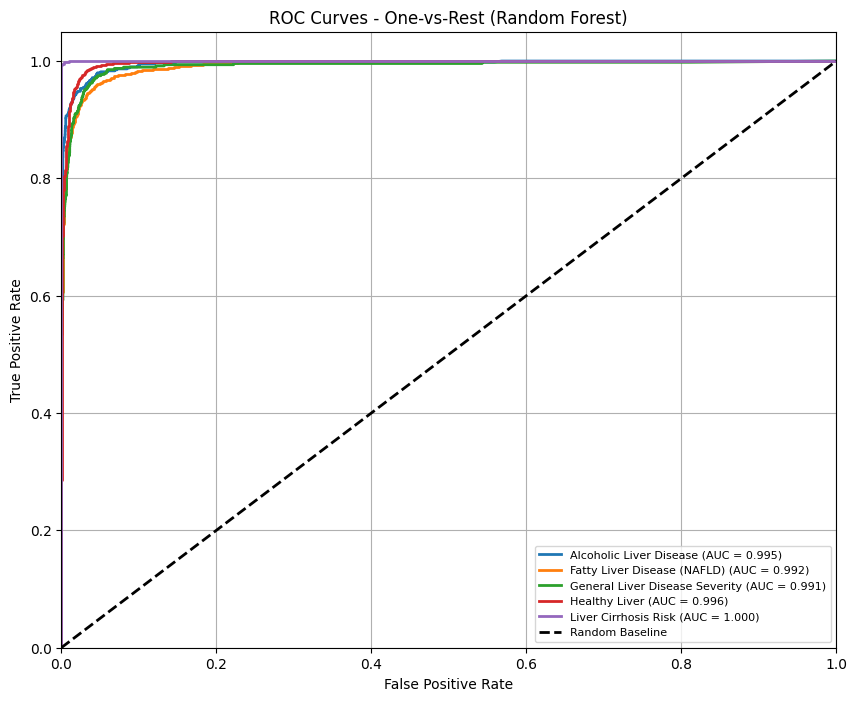

Macro-average AUC: 0.9949
Highest AUC: Liver Cirrhosis Risk (1.000)
Lowest AUC: General Liver Disease Severity (0.991)


In [ ]:
#Task 20 ROC CURVES


y_test_bin = label_binarize(y_test_encoded, classes=range(5))
y_pred_proba = best_rf.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))
auc_scores = []

for i in range(5):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, lw=2, label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - One-vs-Rest (Random Forest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.show()

macro_auc = np.mean(auc_scores)
print(f"Macro-average AUC: {macro_auc:.4f}")
print(f"Highest AUC: {label_encoder.classes_[np.argmax(auc_scores)]} ({max(auc_scores):.3f})")
print(f"Lowest AUC: {label_encoder.classes_[np.argmin(auc_scores)]} ({min(auc_scores):.3f})")